# K-Means calibrado — Country Data

1. Elegimos **k** automáticamente con el **método de silueta**.  
2. Calibramos hiperparámetros con ese **k** fijo.  
3. Graficamos los **3 mejores** modelos.  
4. **PCA biplot** con clúster, nombre del país y variables.

In [ ]:
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Cargar y escalar datos

In [ ]:
df = pd.read_csv("Country-data.csv")
X = df.drop(columns="country").values
X = StandardScaler().fit_transform(X)   #se estandarizaron los datos

print(f"Países: {len(df)} | Variables: {X.shape[1]}")
df.head()

Países: 167 | Variables: 9


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
#metodo de hopkins para evaluación  de clusters
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def hopkins(X, sample_size=None):

    X = np.array(X)

    if sample_size is None:
        sample_size = int(0.1 * len(X))

    X_scaled = StandardScaler().fit_transform(X)

    n, d = X_scaled.shape

    random_indices = np.random.choice(n, sample_size, replace=False)
    X_sample = X_scaled[random_indices]

    mins = np.min(X_scaled, axis=0)
    maxs = np.max(X_scaled, axis=0)

    X_random = np.random.uniform(mins, maxs, (sample_size, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X_scaled)

    u_distances, _ = nbrs.kneighbors(X_sample)
    u = u_distances[:, 1]

    w_distances, _ = nbrs.kneighbors(X_random)
    w = w_distances[:, 0]

    H = np.sum(w) / (np.sum(u) + np.sum(w))

    return H

H = hopkins(X)

print("Hopkins statistic:", H)

Hopkins statistic: 0.8451834434089575


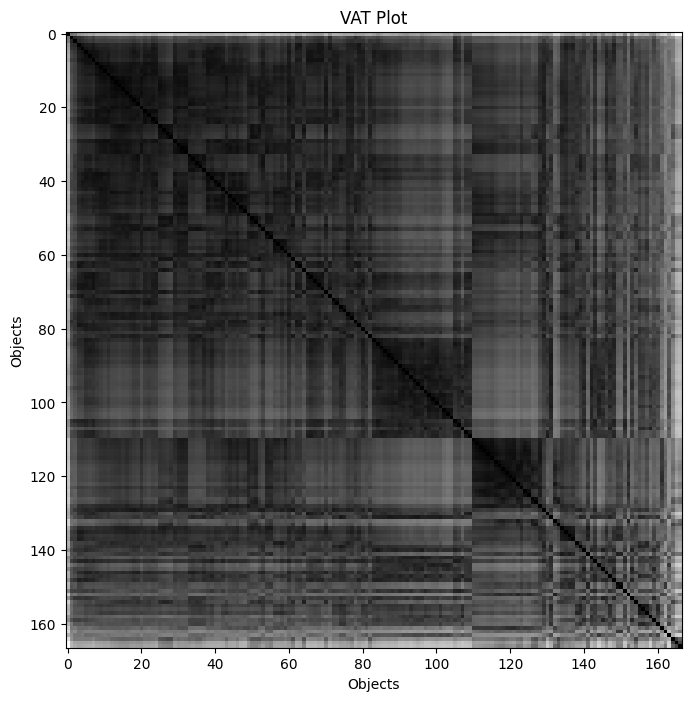

In [ ]:
#metodo vat para la evaluación  de clusters
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform

def VAT(X):

    # Matriz de distancias
    D = squareform(pdist(X))

    n = D.shape[0]

    # Algoritmo VAT
    J = list(range(n))
    I = []

    # Punto inicial
    i = np.argmax(np.sum(D, axis=1))
    I.append(i)
    J.remove(i)

    while len(J) > 0:

        j = J[np.argmin([
            np.min(D[j, I]) for j in J
        ])]

        I.append(j)
        J.remove(j)

    # Reordenar matriz
    D_reordered = D[np.ix_(I, I)]

    # VAT Plot
    plt.figure(figsize=(8,8))

    plt.imshow(D_reordered, cmap='gray')

    plt.title('VAT Plot')
    plt.xlabel('Objects')
    plt.ylabel('Objects')

    plt.show()

VAT(X)

## 2. Elegir k automáticamente (método de silueta)

Para cada **k** posible entrenamos un K-Means y calculamos el **coeficiente de silueta medio**.  
El **k óptimo** es el que maximiza esa silueta.

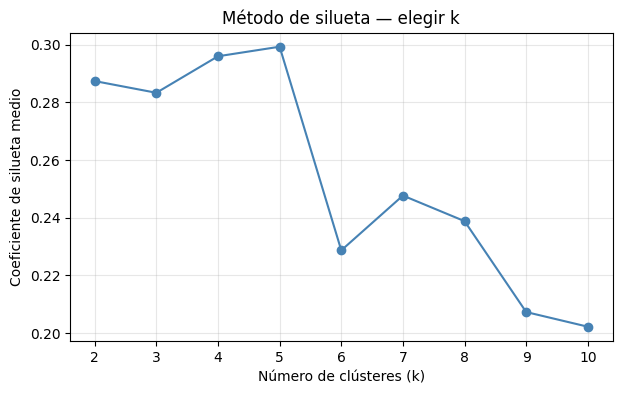

k óptimo (automático): 5  |  silueta = 0.299


In [ ]:
K_CANDIDATOS = range(2, 11)    #va de 2 hasta 11 clusters
METRICA_K = "euclidean"        #en base a la distancia euclidiana, también tienen que calibrarse los metodos para calcular clusters la inercia como silhouette_score

sil_por_k = []    #se agrega la cantidad del metodo de silhouette y se almacena para poder cuantificarlos
for k in K_CANDIDATOS:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)   #se utiliza kmeans para sacar esa inercia
    etiquetas = modelo.fit_predict(X)
    sil_por_k.append(silhouette_score(X, etiquetas, metric=METRICA_K))     #se utiliza silhoutte_score

#se grafica
plt.figure(figsize=(7, 4))
plt.plot(list(K_CANDIDATOS), sil_por_k, "o-", color="steelblue")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Coeficiente de silueta medio")
plt.title("Método de silueta — elegir k")
plt.grid(alpha=0.3)
plt.show()

K_OPTIMO = list(K_CANDIDATOS)[np.argmax(sil_por_k)]
print(f"k óptimo (automático): {K_OPTIMO}  |  silueta = {max(sil_por_k):.3f}")

## 3. Calibración de hiperparámetros (con k fijo)

Con **k = K_OPTIMO** probamos **init**, **n_init** y **max_iter**.  
Evaluamos cada modelo con varias métricas de distancia.

In [ ]:

INITS = ["k-means++", "random"]    #inits para inicializar los centroides
N_INITS = [10, 20]               #la cantidad de veces que los centroides se resetean
MAX_ITERS = [100, 300]          #la cantidad de iteraciones que va a tener el modelo para formar los clusters
METRICAS = ["euclidean", "manhattan", "cosine", "chebyshev"]    #metricas de las distancias

resultados = []    #los resultados se guardan

for init, n_init, max_iter in itertools.product(INITS, N_INITS, MAX_ITERS):    #tengo un for que me itera cada uno de esos hiperparametros
    modelo = KMeans(
        n_clusters=K_OPTIMO,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    etiquetas = modelo.fit_predict(X)

    for metrica in METRICAS:             #tambien se itera sobre las metricas
        sil = silhouette_score(X, etiquetas, metric=metrica)
        resultados.append({
            "k": K_OPTIMO,           #k optimo (ojo que arriba se le pone que son 5)
            "init": init,
            "n_init": n_init,
            "max_iter": max_iter,
            "metrica": metrica,     #funcion de la distancia
            "silueta": sil,         #silhoutte
            "etiquetas": etiquetas.copy(),   #esta no tiene sentido
        })

ranking = pd.DataFrame(resultados).sort_values("silueta", ascending=False)
ranking[["k", "init", "n_init", "max_iter", "metrica", "silueta"]].head(10)

,k,init,n_init,max_iter,metrica,silueta
1,5,k-means++,10,100,manhattan,0.323903
5,5,k-means++,10,300,manhattan,0.323903
13,5,k-means++,20,300,manhattan,0.323903
9,5,k-means++,20,100,manhattan,0.323903
8,5,k-means++,20,100,euclidean,0.299259
12,5,k-means++,20,300,euclidean,0.299259
4,5,k-means++,10,300,euclidean,0.299259
0,5,k-means++,10,100,euclidean,0.299259
26,5,random,20,100,cosine,0.264173
30,5,random,20,300,cosine,0.264173


## 4. Los 3 mejores (configuraciones distintas)

In [ ]:
#las mejores 3 configuraciones (se repite, pero con el top 3)
top3 = []
vistos = set()

for _, fila in ranking.iterrows():
    clave = (fila["k"], fila["init"], fila["n_init"], fila["max_iter"])
    if clave in vistos:
        continue
    vistos.add(clave)
    top3.append(fila)
    if len(top3) == 3:
        break

for i, f in enumerate(top3, 1):
    print(
        f"{i}. k={f['k']}, init={f['init']}, n_init={f['n_init']}, "
        f"max_iter={f['max_iter']} | silueta ({f['metrica']}) = {f['silueta']:.3f}"
    )

1. k=5, init=k-means++, n_init=10, max_iter=100 | silueta (manhattan) = 0.324
2. k=5, init=k-means++, n_init=10, max_iter=300 | silueta (manhattan) = 0.324
3. k=5, init=k-means++, n_init=20, max_iter=300 | silueta (manhattan) = 0.324


## 5. Gráficos de silueta — top 3

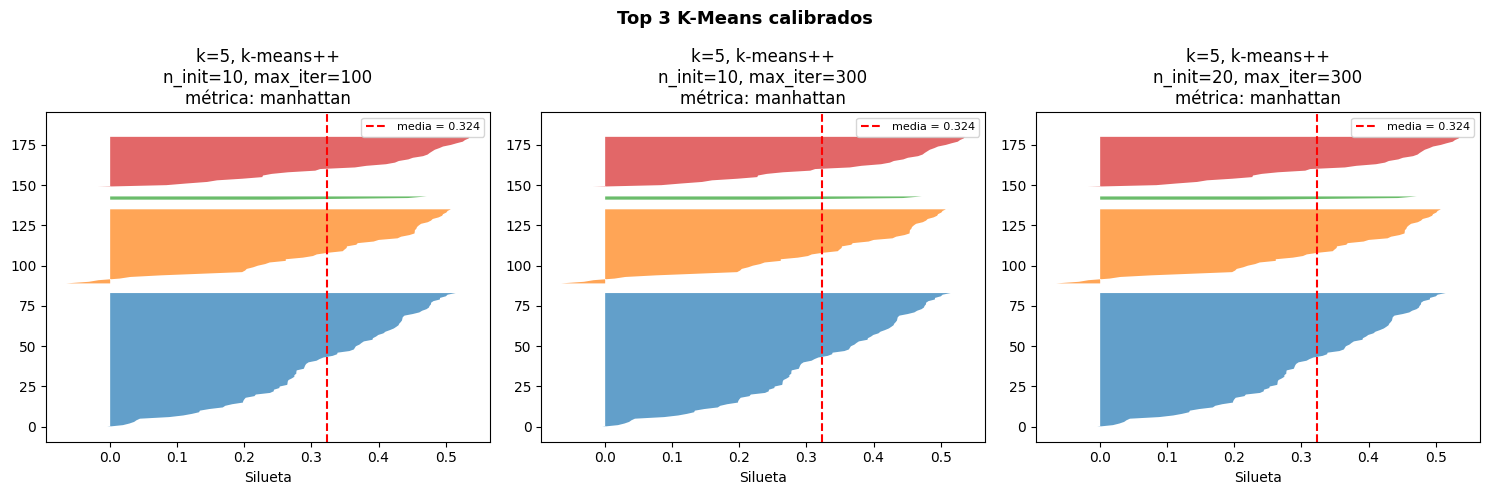

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fila in zip(axes, top3):
    etiquetas = fila["etiquetas"]
    metrica = fila["metrica"]
    k = int(fila["k"])
    sil_vals = silhouette_samples(X, etiquetas, metric=metrica)
    sil_media = fila["silueta"]

    y = 0
    for i in range(k):
        vals = np.sort(sil_vals[etiquetas == i])
        ax.fill_betweenx(range(y, y + len(vals)), 0, vals, alpha=0.7)
        y += len(vals) + 5

    ax.axvline(sil_media, color="red", linestyle="--", label=f"media = {sil_media:.3f}")
    ax.set_title(
        f"k={k}, {fila['init']}\n"
        f"n_init={fila['n_init']}, max_iter={fila['max_iter']}\n"
        f"métrica: {metrica}"
    )
    ax.set_xlabel("Silueta")
    ax.legend(fontsize=8)

plt.suptitle("Top 3 K-Means calibrados", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Método del codo (solo referencia)

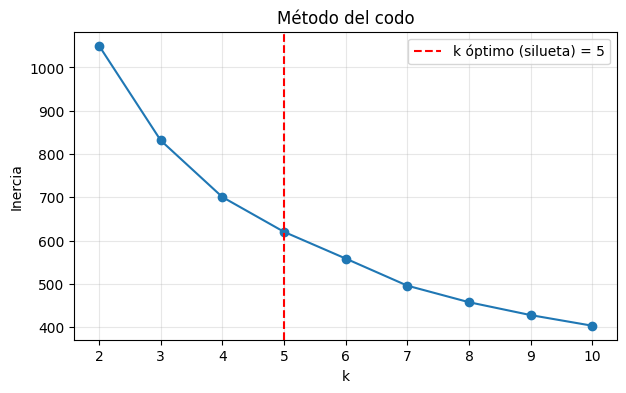

In [ ]:
#metodo del codo de jambu
inercias = []
for k in K_CANDIDATOS:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_CANDIDATOS), inercias, "o-")
plt.axvline(K_OPTIMO, color="red", linestyle="--", label=f"k óptimo (silueta) = {K_OPTIMO}")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. PCA biplot — grupos, clúster y país

Visualización en 2 componentes principales del **mejor modelo**.  
Cada punto es un país (con su nombre), el color es el **clúster** y las flechas son las variables.

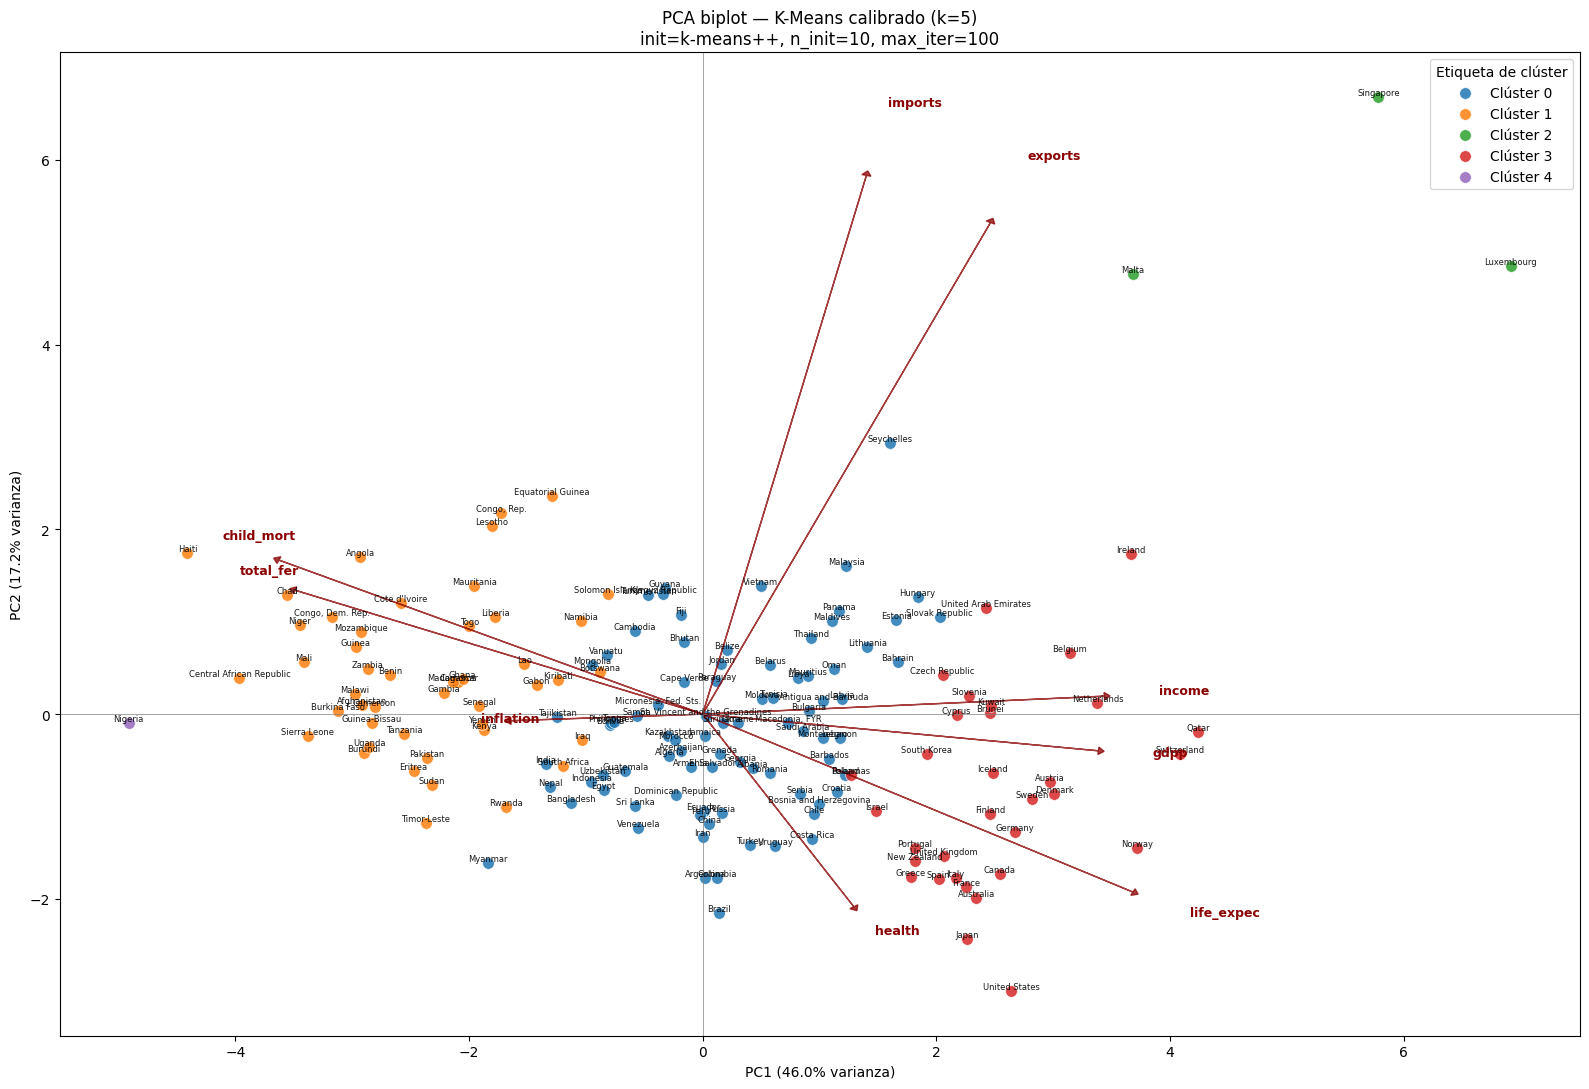

In [ ]:
#aplicacion del pca
# Mejor modelo (top 1)
mejor = top3[0]
etiquetas_final = mejor["etiquetas"].astype(int)
paises = df["country"].values
variables = df.drop(columns="country").columns

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
loadings = pca.components_.T  # variables x 2

fig, ax = plt.subplots(figsize=(16, 11))

# Puntos por clúster + etiqueta de país
for c in sorted(np.unique(etiquetas_final)):
    mask = etiquetas_final == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"Clúster {c}",
        s=70, alpha=0.85, edgecolors="white", linewidths=0.5,
    )
    for i in np.where(mask)[0]:
        ax.annotate(
            paises[i],
            (X_pca[i, 0], X_pca[i, 1]),
            fontsize=6,
            ha="center",
            va="bottom",
            alpha=0.9,
        )

# Biplot: flechas de las variables
escala = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.85
for j, var in enumerate(variables):
    ax.arrow(
        0, 0,
        loadings[j, 0] * escala, loadings[j, 1] * escala,
        head_width=0.08, head_length=0.05,
        fc="darkred", ec="darkred", alpha=0.75, length_includes_head=True,
    )
    ax.text(
        loadings[j, 0] * escala * 1.12,
        loadings[j, 1] * escala * 1.12,
        var, color="darkred", fontsize=9, fontweight="bold",
    )

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)")
ax.set_title(
    f"PCA biplot — K-Means calibrado (k={K_OPTIMO})\n"
    f"init={mejor['init']}, n_init={mejor['n_init']}, max_iter={mejor['max_iter']}"
)
ax.legend(title="Etiqueta de clúster", loc="best")
plt.tight_layout()
plt.show()